In [2]:
# ─────────────────────────────────────────────
# 첫 실행 — 환경이 잘 갖춰졌는지 한 번에 확인
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ numpy     :", np.__version__)
print("✅ pandas    :", pd.__version__)
print("✅ matplotlib:", matplotlib.__version__)
print()

✅ numpy     : 2.5.0
✅ pandas    : 3.0.3
✅ matplotlib: 3.11.0



In [3]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
display(bike.head())
display(bike.tail())

## 
display(bike["date"].sort_values(ascending=False).head())


따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


,date,rentals,avg_temp,rainfall,station_area
176,2025-06-26,3516.0,22.9,0,강남
177,2025-06-27,3312.0,27.8,0,송파
178,2025-06-28,2514.0,27.4,0,송파
179,2025-06-29,3266.0,26.4,0,강남
180,2025-01-04,3295.0,0.9,0,강남


179   2025-06-29
178   2025-06-28
177   2025-06-27
176   2025-06-26
175   2025-06-25
Name: date, dtype: datetime64[us]

In [4]:
# 시나리오 1 — 구조 진단
print("shape:", bike.shape)
bike.info()
display(bike.describe())

shape: (181, 5)
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


In [5]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


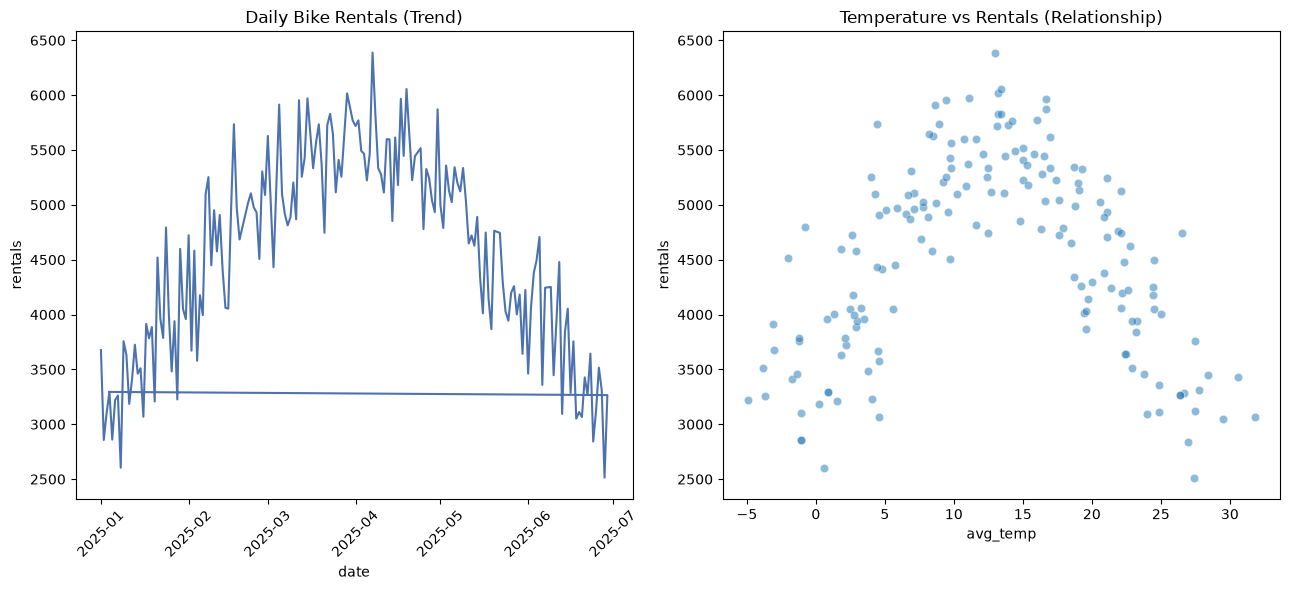

In [6]:
# 시나리오 3 — 시각화 (이상치 제거 후)
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); 
plt.show()

# 따릉이 대여 데이터 — 기초 EDA 리포트

## 1. 데이터 개요
- 행/열: (181행, 5열)
- 기간: 2025-01-01 ~ 2025-06-29
- 주요 컬럼: date, rentals, avg_temp, rainfall, station_area

## 2. 구조 진단 (shape / info / describe)
- 자료형 요약: (날짜 열은 datetime으로 인식됨 / rentals, avg_temp는 float64 / rainfalls는 int64 / stattion_area는 str)
- 수치 요약에서 눈에 띈 점: (rentals 평균 4531.757225, avg_temp 최댓값 250 → 이상치 의심)

## 3. 품질 진단 (결측 / 중복 / 표기)
- 결측: rentals 8건
- 중복: 1건
- 표기 혼재: station_area에 ' 강남 '(공백) 존재

## 4. 패턴 (시각화에서 읽은 것)
- 추이: (계절성 — 봄~여름 증가 등)
        봄인 4월 경에 rentals가 최대치 기록하며, 4월 이전 이후로는 감소하는 모습을 보임
- 관계: (기온과 대여 수의 양의 관계 등)
        기온이 10~15도 일때 대여수가 최대치이며, 기온이 10~15도보다 낮게나 높을 때(춥거나 더울 때) 대여수가 감소하는 모습을 보임

## 5. 다음 분석 제안
- (이상치/결측을 어떻게 처리할지, 추가로 보고 싶은 것)
- 이상치(기온)은 전일, 익일 기온의 평균값으로 대체하는 것이 좋을 거 같음
- 결측치 또한 전일, 익일의 평균값으로 대체하는 것이 좋을 거 같음
- 추가로, stataion_area에 따른 rentals를 분석해보고 싶음